# Tracer advection scheme 30 vs 33: what the flux limiter does to the forward state (2026-09-10)

One-setting twins restarted from the 2× spin-up's year-170 pickup with the reference viscosity and `viscAhReMax=2.` (the 2026-09-09 production viscosity), differing **only** in `tempAdvScheme=saltAdvScheme`: 33 (DST3 with the Sweby flux limiter, the DINO-like monotone scheme) against 30 (the same scheme without the limiter, the production scheme since 2026-09-09).

| pair | scheme 33 | scheme 30 | length |
| --- | --- | --- | --- |
| 2 yr | 31160 `from170yrPk_viscRef_ReMax2` | 31174 `from170yrPk_viscRef_ReMax2_adv30` | months 12–24 averaged |
| 10 yr | 31164 | 31175 | months 109–120 averaged |

Namelists: `input/variants/stability_study/`. Question raised: whether the unlimited scheme makes the overturning cells "extend too deep" (an advisor's recollection of an earlier scheme-30 run), and whether the scheme-30 tracer field over/undershoots. Diagnostics: the depth-space MOC (`dinocean`'s `compute_moc_diagnostics`, zonally integrated `VVEL` cumulated from the bottom), per-latitude cell metrics, tracer excursions outside the limited run's own range, `MXLDEPTH` statistics, zonal-mean T/S/ρ and w differences. Figures go to `analysis/stability_study/figures/` on scratch (a multi-run product), never into the repository. The adjoint side of the same question (the flux limiter's adjoint, the approximate adjoint, the gradient check) is in the setup README's "Scheme 30 or scheme 33" and in `input_tap/variants/{stability_study,grdchk_repair}/README.md`.

In [1]:
import os, glob, warnings
import numpy as np, xarray as xr, xmitgcm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from dinocean.neverworld2.loader import DINOLoader

SCRATCH = '/scratch2/tshahriar/DINO_1deg_outputs'
RUNS = SCRATCH + '/runs/forward'
FIG_DIR = SCRATCH + '/analysis/stability_study/figures'      # multi-run analysis product: analysis/<campaign>/
os.makedirs(FIG_DIR, exist_ok=True)
MON = 1464                                                    # steps per 30.5-d diagnostic interval
PAIRS = {
    '2yr':  dict(adv33=RUNS + '/stability_study/DINO_1deg_frd_2yr_from170yrPk_viscRef_ReMax2_run31160',
                 adv30=RUNS + '/stability_study/DINO_1deg_frd_2yr_from170yrPk_viscRef_ReMax2_adv30_run31174',  it_last=3021696),
    '10yr': dict(adv33=RUNS + '/stability_study/DINO_1deg_frd_10yr_from170yrPk_viscRef_ReMax2_run31164',
                 adv30=RUNS + '/stability_study/DINO_1deg_frd_10yr_from170yrPk_viscRef_ReMax2_adv30_run31175', it_last=3162240),
}
for k, p in PAIRS.items():
    for s in ('adv33', 'adv30'):
        assert os.path.isdir(p[s]), p[s]

In [2]:
def load(run_dir, it_last, nmon=12):
    iters = [it_last - k * MON for k in range(nmon)][::-1]
    have = sorted(int(os.path.basename(f).split('.')[1]) for f in glob.glob(run_dir + '/dynDiag.*.meta'))
    its = [i for i in iters if i in have]
    d = DINOLoader(run_dir, prefix=['dynDiag', 'surfDiag'], geometry='curvilinear', delta_t=1800., iters=its)
    d.compute_moc_diagnostics(target_lat=26.)
    return d, its

def cell_metrics(psi, z):
    """per latitude: upper-cell max [Sv], its depth, the depth where psi falls to 5 % of it (cell bottom), deep min [Sv]"""
    P = psi.transpose('k', 'j_g').values; out = []
    for j in range(P.shape[1]):
        col = P[:, j]
        if not np.isfinite(col).any(): out.append((np.nan,) * 4); continue
        km = np.nanargmax(col); pmax = col[km]
        kb = next((k for k in range(km, len(col)) if col[k] <= 0.05 * pmax), len(col) - 1)
        out.append((pmax, z[km], z[kb], np.nanmin(col)))
    return np.array(out)

def compare_pair(name, adv30, adv33, it_last):
    d30, its30 = load(adv30, it_last); d33, its33 = load(adv33, it_last)
    print(f'== {name}: iterations {its30[0]}..{its30[-1]} ({len(its30)} months), ending year {its30[-1]/48/366:.1f}')
    psi30, psi33 = d30.psi_moc.mean('time'), d33.psi_moc.mean('time')
    z = d30.ds['Z'].values; lat = psi30.YC.values
    c30, c33 = cell_metrics(psi30, z), cell_metrics(psi33, z)
    print(' lat     upper max [Sv]      depth of max [m]     cell bottom (5%) [m]    deep min [Sv]')
    print('         adv30   adv33      adv30    adv33       adv30    adv33          adv30   adv33')
    for j in range(0, len(lat), 8):
        a, b = c30[j], c33[j]
        print(f'{lat[j]:6.1f}  {a[0]:6.2f}  {b[0]:6.2f}    {a[1]:8.0f} {b[1]:8.0f}    {a[2]:8.0f} {b[2]:8.0f}      {a[3]:7.2f} {b[3]:7.2f}')
    j26 = int(np.abs(lat - 26).argmin())
    for nm, psi in (('adv30', psi30), ('adv33', psi33)):
        P = psi.transpose('k', 'j_g').values
        print(f'{nm}: max psi {np.nanmax(P):.2f} Sv, min psi {np.nanmin(P):.2f} Sv; at 26N: max {np.nanmax(P[:, j26]):.2f} Sv, '
              f'at 2000 m {P[np.abs(z + 2000).argmin(), j26]:.2f} Sv, at 3000 m {P[np.abs(z + 3000).argmin(), j26]:.2f} Sv')
    # tracer excursions: the limited run's own range at the same time is the envelope
    wet = d30.ds.hFacC > 0
    for v in ('THETA', 'SALT'):
        f30, f33 = d30.ds[v], d33.ds[v]
        lo, hi = float(f33.where(wet).min()), float(f33.where(wet).max())
        under = (f30 < lo - 1e-3) & wet; over = (f30 > hi + 1e-3) & wet
        nu, no = int(under.sum() / f30.sizes['time']), int(over.sum() / f30.sizes['time'])
        print(f'{v}: adv33 range [{lo:.4f}, {hi:.4f}]  adv30 range [{float(f30.where(wet).min()):.4f}, {float(f30.where(wet).max()):.4f}]  '
              f'cells/month below adv33 min: {nu}, above adv33 max: {no} (of {int(wet.sum())} wet)')
    for nm, d in (('adv30', d30), ('adv33', d33)):
        m = d.ds.MXLDEPTH.where(wet.isel(k=0)); area = (wet.isel(k=0) * d.ds.rA).sum()
        print(f'{nm}: MXLDEPTH mean {float(m.mean()):.1f} m, max {float(m.max()):.0f} m, area deeper than 500 m {float(((m > 500) * d.ds.rA).sum() / area) * 100:.2f} %, than 1000 m {float(((m > 1000) * d.ds.rA).sum() / area) * 100:.2f} %')
    # figure
    fig, ax = plt.subplots(1, 3, figsize=(17, 5), sharey=True); lev = np.linspace(-20, 20, 21)
    for a, psi, t in zip(ax[:2], (psi30, psi33), (f'scheme 30 ({os.path.basename(adv30)[-8:]})', f'scheme 33 ({os.path.basename(adv33)[-8:]})')):
        cf = a.contourf(lat, z, psi.transpose('k', 'j_g').values, levels=lev, cmap='RdBu_r', extend='both')
        a.contour(lat, z, psi.transpose('k', 'j_g').values, levels=lev, colors='k', linewidths=0.4); a.set_title(t); a.set_xlabel('latitude')
    cf2 = ax[2].contourf(lat, z, (psi30 - psi33).transpose('k', 'j_g').values, levels=np.linspace(-4, 4, 17), cmap='PuOr_r', extend='both')
    ax[2].set_title('scheme 30 minus scheme 33'); ax[2].set_xlabel('latitude'); ax[0].set_ylabel('depth [m]')
    fig.colorbar(cf, ax=ax[:2], label='Sv'); fig.colorbar(cf2, ax=ax[2], label='Sv')
    fig.suptitle(f'depth-space MOC, 12-month mean ending iteration {its30[-1]} ({its30[-1]/48/366:.1f} yr): {name}')
    fig.savefig(f'{FIG_DIR}/moc_depth_from170yrPk_{name}_adv30_vs_adv33_same_viscRefReMax2.png', dpi=110, bbox_inches='tight')
    return d30, d33

## 2-year twins (31174 vs 31160), months 12–24

== 2yr: iterations 3005592..3021696 (12 months), ending year 172.0
 lat     upper max [Sv]      depth of max [m]     cell bottom (5%) [m]    deep min [Sv]
         adv30   adv33      adv30    adv33       adv30    adv33          adv30   adv33
 -69.9    0.00    0.00          -5       -5          -5       -5         0.00    0.00
 -66.9    0.59    0.49        -915     -915       -2115    -1844        -0.68   -0.70
 -63.6    0.78    0.90       -2115    -1059       -2795    -2795        -0.23   -0.20
 -59.8    1.50    1.77         -15     -791       -2795    -2795        -0.56   -0.52
 -55.5    3.15    3.35        -791     -791       -3223    -3223        -0.67   -0.55
 -50.7    5.42    5.55       -2429    -2429       -3223    -3727         0.00    0.00
 -45.4    7.52    7.58        -231     -178       -3223    -3727         0.00    0.00
 -39.5    7.69    7.68          -5       -5       -3223    -3223        -0.68   -0.34
 -33.0    6.27    6.33        -103     -119       -1220    -1220      

THETA: adv33 range [-0.4633, 27.6691]  adv30 range [-0.0905, 27.7716]  cells/month below adv33 min: 0, above adv33 max: 1 (of 332274 wet)


SALT: adv33 range [35.0065, 37.0007]  adv30 range [35.0083, 37.0007]  cells/month below adv33 min: 0, above adv33 max: 0 (of 332274 wet)
adv30: MXLDEPTH mean 12.1 m, max 2418 m, area deeper than 500 m 0.72 %, than 1000 m 0.55 %


adv33: MXLDEPTH mean 12.2 m, max 2992 m, area deeper than 500 m 0.66 %, than 1000 m 0.49 %


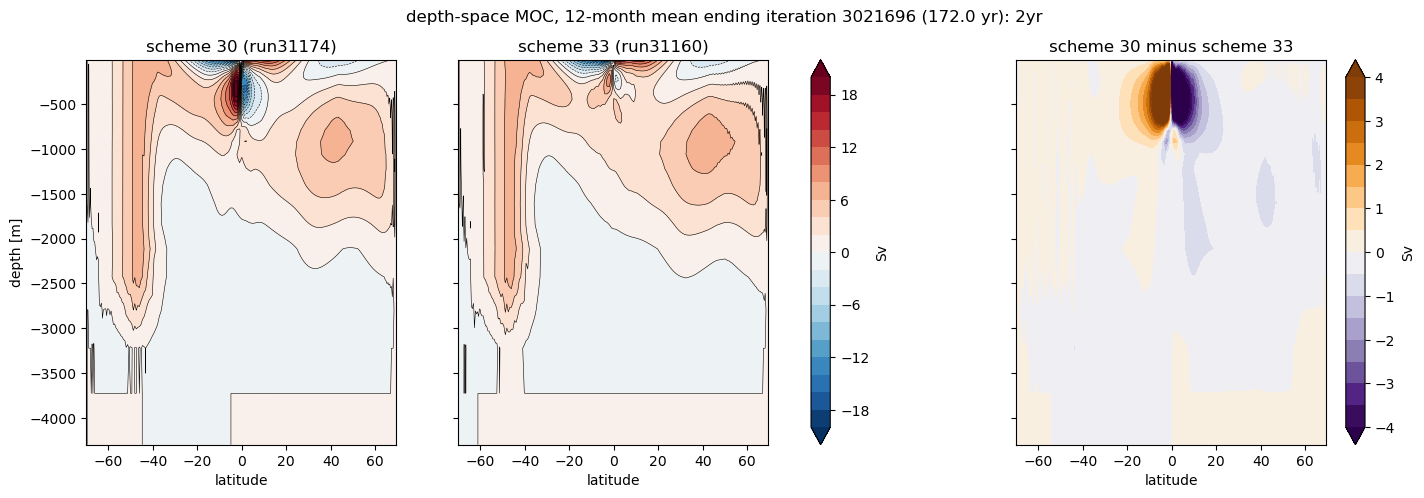

In [3]:
d30_2, d33_2 = compare_pair('2yr', **PAIRS['2yr'])

## 10-year twins (31175 vs 31164), months 109–120

== 10yr: iterations 3146136..3162240 (12 months), ending year 180.0
 lat     upper max [Sv]      depth of max [m]     cell bottom (5%) [m]    deep min [Sv]
         adv30   adv33      adv30    adv33       adv30    adv33          adv30   adv33
 -69.9    0.00    0.00          -5       -5          -5       -5         0.00    0.00
 -66.9    0.38    0.27        -791     -684       -1844    -1608        -0.87   -0.99
 -63.6    0.56    0.78       -2115    -2115       -2795    -2795        -0.46   -0.44
 -59.8    1.55    1.50       -2115      -15       -2795    -2795        -0.99   -1.03
 -55.5    3.29    3.24        -791    -1402       -3223    -3223        -0.89   -0.86
 -50.7    5.41    5.54       -2429    -2429       -3223    -3223        -0.21   -0.00
 -45.4    7.70    7.62        -300     -231       -3223    -3727        -0.00   -0.00
 -39.5    7.69    7.66          -5       -5       -2429    -3223        -1.08   -0.63
 -33.0    6.51    6.21        -119     -103       -1059    -1059     

THETA: adv33 range [-0.4301, 27.6854]  adv30 range [-0.0969, 27.8017]  cells/month below adv33 min: 0, above adv33 max: 1 (of 332274 wet)


SALT: adv33 range [35.0058, 37.0006]  adv30 range [35.0079, 37.0010]  cells/month below adv33 min: 0, above adv33 max: 0 (of 332274 wet)
adv30: MXLDEPTH mean 11.2 m, max 2316 m, area deeper than 500 m 0.56 %, than 1000 m 0.47 %


adv33: MXLDEPTH mean 11.3 m, max 2447 m, area deeper than 500 m 0.49 %, than 1000 m 0.37 %


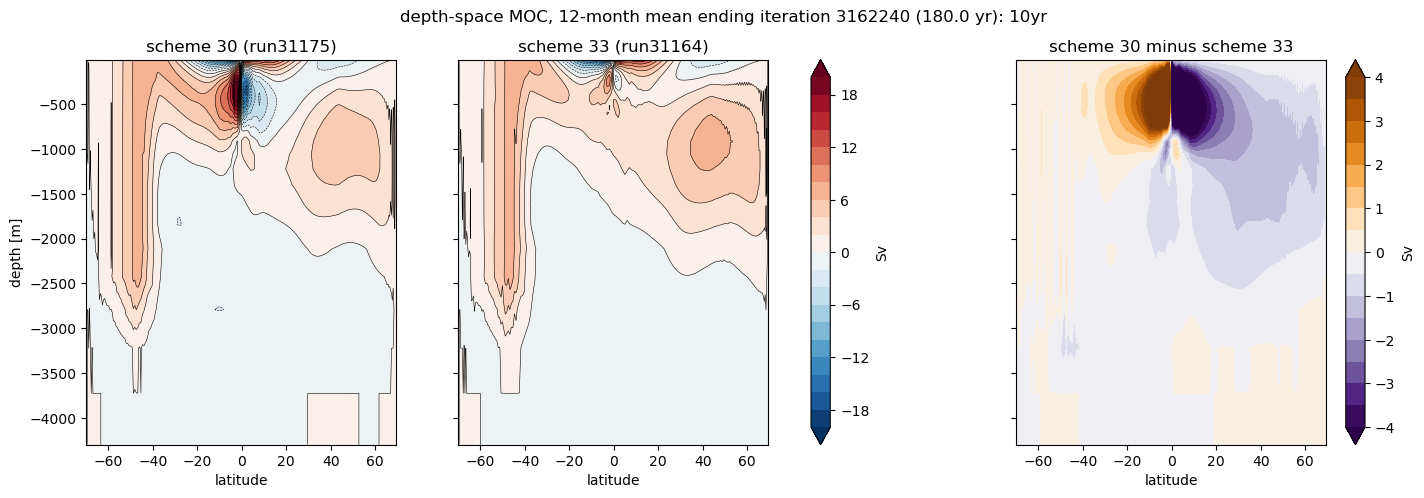

In [4]:
d30_10, d33_10 = compare_pair('10yr', **PAIRS['10yr'])

## Where the difference lives: zonal means

Zonal-mean T, S, density anomaly and vertical velocity, scheme 30 minus scheme 33, over the same 12 months. The equatorial band is the whole story: a colder, sharper equatorial thermocline under the unlimited scheme, with upwelling confined to the top 150 m instead of 400 m — the limiter, active where the thermocline is sharp and w large, acts as extra vertical mixing there.

2yr: equatorial band (|lat| < ~6): zonal-mean T, S and w, scheme 30 vs 33
   z=    -26  T  17.91 vs  18.83   S  36.505 vs  36.494   w   0.291 vs   0.305 m/d
   z=    -37  T  15.97 vs  16.87   S  36.549 vs  36.549   w   0.255 vs   0.275 m/d
   z=    -49  T  14.75 vs  15.48   S  36.550 vs  36.560   w   0.221 vs   0.247 m/d
   z=    -61  T  14.00 vs  14.53   S  36.523 vs  36.534   w   0.187 vs   0.218 m/d
   z=    -74  T  13.53 vs  13.91   S  36.487 vs  36.494   w   0.153 vs   0.189 m/d
   z=    -88  T  13.19 vs  13.48   S  36.455 vs  36.454   w   0.120 vs   0.161 m/d
   z=   -103  T  12.92 vs  13.15   S  36.428 vs  36.421   w   0.088 vs   0.135 m/d
   z=   -119  T  12.69 vs  12.87   S  36.406 vs  36.395   w   0.057 vs   0.109 m/d
   z=   -137  T  12.48 vs  12.63   S  36.387 vs  36.373   w   0.028 vs   0.085 m/d
   z=   -156  T  12.29 vs  12.42   S  36.369 vs  36.355   w  -0.001 vs   0.063 m/d
   z=   -178  T  12.12 vs  12.24   S  36.354 vs  36.340   w  -0.029 vs   0.042 m/d
   z=   -203 

10yr: equatorial band (|lat| < ~6): zonal-mean T, S and w, scheme 30 vs 33
   z=    -26  T  17.89 vs  18.78   S  36.485 vs  36.496   w   0.288 vs   0.305 m/d
   z=    -37  T  15.68 vs  16.80   S  36.519 vs  36.550   w   0.252 vs   0.275 m/d
   z=    -49  T  14.23 vs  15.40   S  36.511 vs  36.561   w   0.216 vs   0.246 m/d
   z=    -61  T  13.35 vs  14.47   S  36.478 vs  36.536   w   0.180 vs   0.217 m/d
   z=    -74  T  12.84 vs  13.85   S  36.442 vs  36.496   w   0.145 vs   0.189 m/d
   z=    -88  T  12.53 vs  13.44   S  36.414 vs  36.459   w   0.111 vs   0.161 m/d
   z=   -103  T  12.28 vs  13.11   S  36.392 vs  36.428   w   0.078 vs   0.135 m/d
   z=   -119  T  12.08 vs  12.85   S  36.375 vs  36.404   w   0.046 vs   0.110 m/d
   z=   -137  T  11.91 vs  12.61   S  36.362 vs  36.383   w   0.015 vs   0.086 m/d
   z=   -156  T  11.77 vs  12.41   S  36.353 vs  36.366   w  -0.016 vs   0.064 m/d
   z=   -178  T  11.65 vs  12.24   S  36.347 vs  36.354   w  -0.046 vs   0.043 m/d
   z=   -203

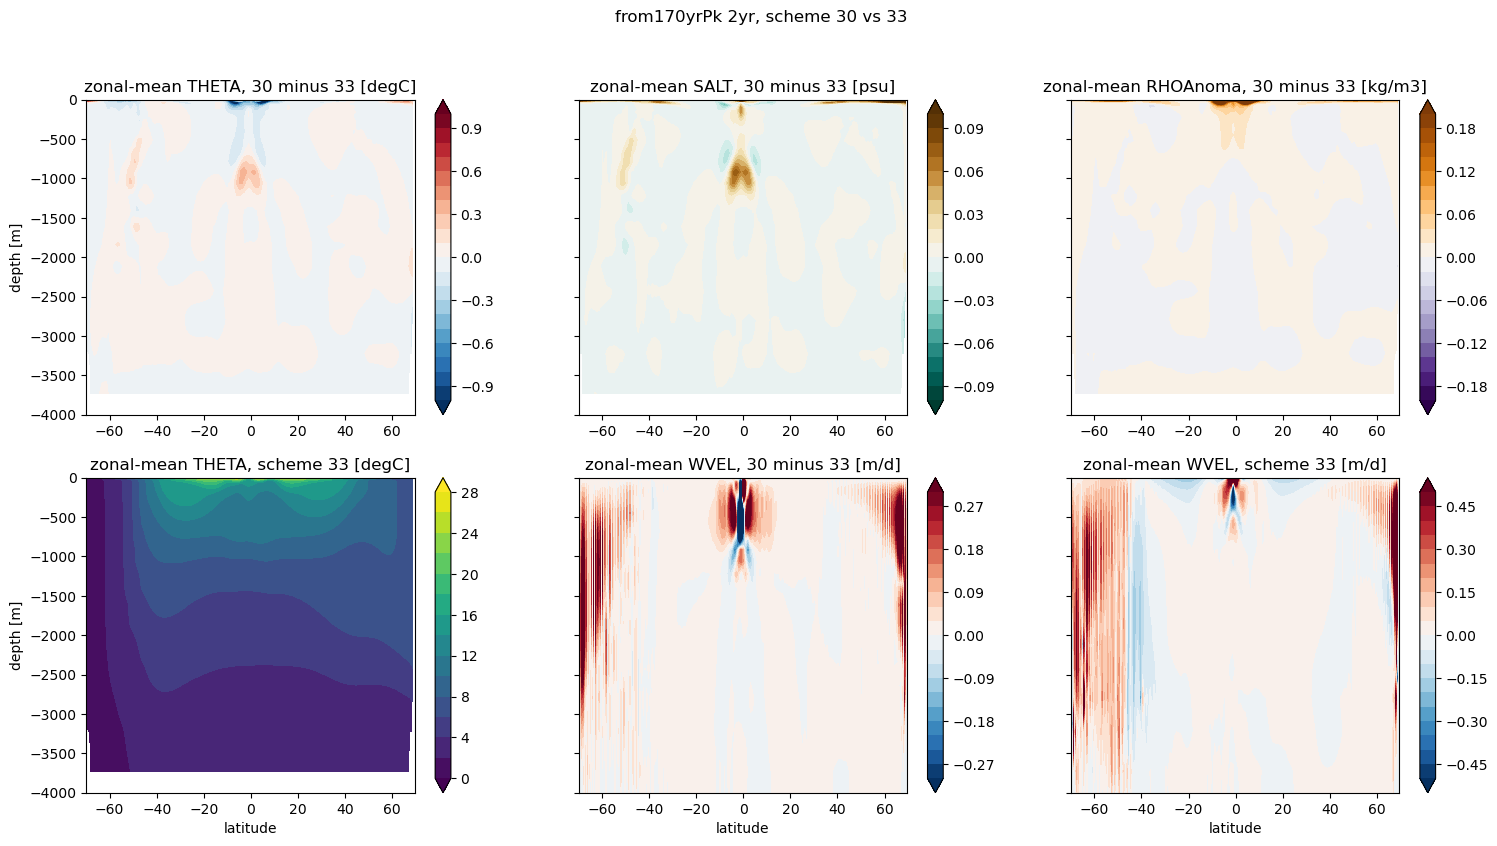

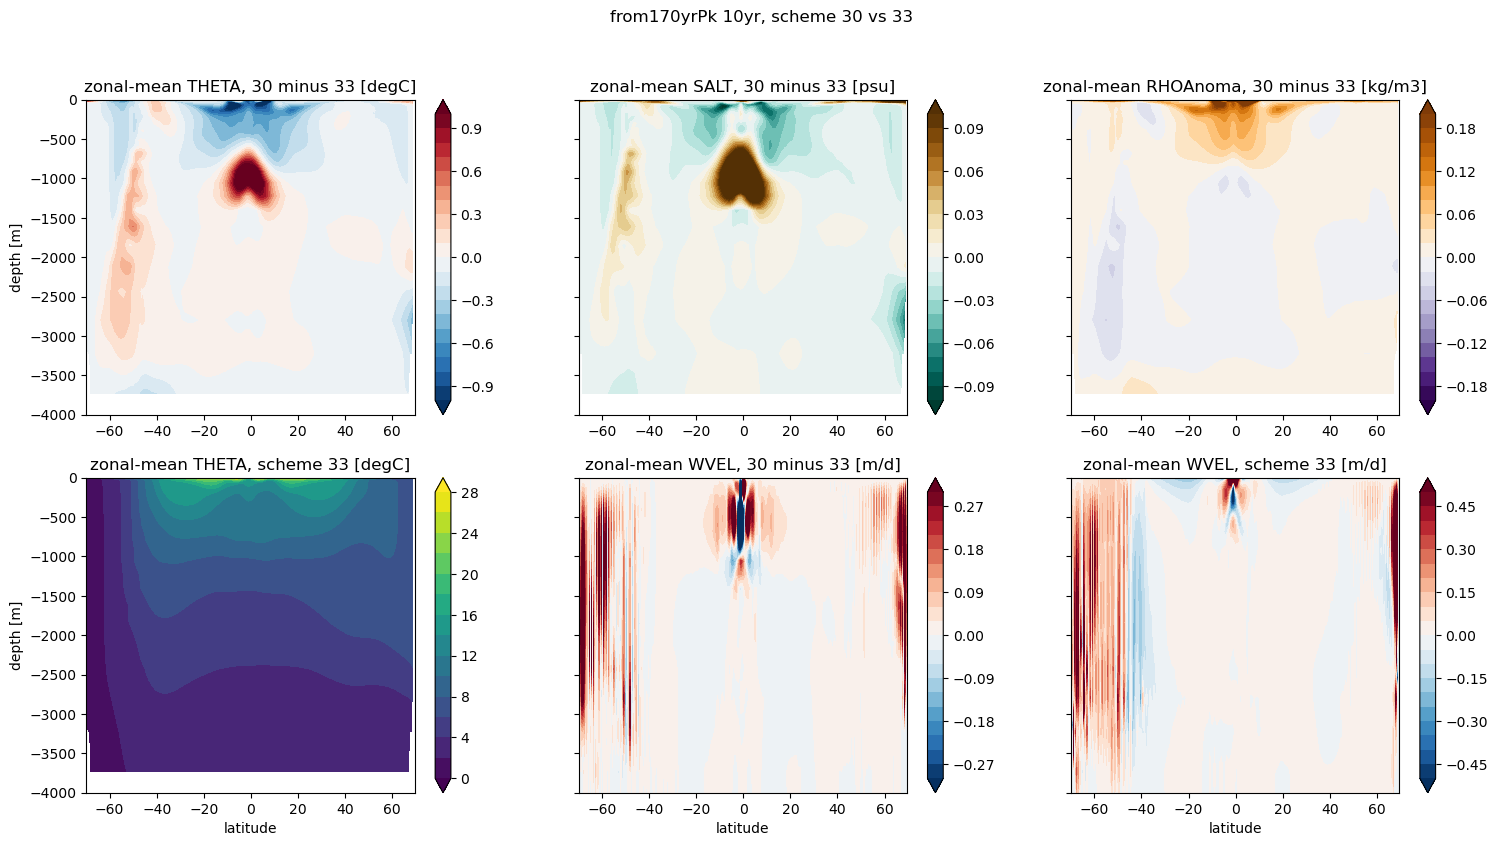

In [5]:
def zonal_diff(name, d30, d33):
    wet = d30.ds.hFacC > 0; lat = d30.ds.YC.isel(i=0).values; z = d30.ds.Z.values
    def zm(ds, v):
        w = ds.hFacC * ds.rA
        return ((ds[v] * w).sum('i') / w.sum('i')).mean('time').where(wet.any('i')).transpose('k', 'j').values
    def wz(ds):
        m = (ds.hFacC > 0).rename({'k': 'k_l'}).assign_coords(k_l=ds.k_l)
        return (ds.WVEL.mean('time') * m).mean('i').transpose('k_l', 'j').values * 86400
    T30, T33 = zm(d30.ds, 'THETA'), zm(d33.ds, 'THETA'); S30, S33 = zm(d30.ds, 'SALT'), zm(d33.ds, 'SALT')
    R30, R33 = zm(d30.ds, 'RHOAnoma'), zm(d33.ds, 'RHOAnoma'); W30, W33 = wz(d30.ds), wz(d33.ds)
    band = slice(max(int(np.abs(lat).argmin()) - 6, 0), int(np.abs(lat).argmin()) + 7)
    print(f'{name}: equatorial band (|lat| < ~6): zonal-mean T, S and w, scheme 30 vs 33')
    for k in range(len(z)):
        if -400 < z[k] < -20:
            print(f'   z={z[k]:7.0f}  T {np.nanmean(T30[k, band]):6.2f} vs {np.nanmean(T33[k, band]):6.2f}   S {np.nanmean(S30[k, band]):7.3f} vs {np.nanmean(S33[k, band]):7.3f}   w {np.nanmean(W30[k, band]):7.3f} vs {np.nanmean(W33[k, band]):7.3f} m/d')
    print('rms(T30 - T33) per level, top 12:', ' '.join(f'{np.sqrt(np.nanmean((T30[k] - T33[k])**2)):.3f}' for k in range(12)))
    fig, ax = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
    for a, F, t, lev, cm in ((ax[0, 0], T30 - T33, 'zonal-mean THETA, 30 minus 33 [degC]', np.linspace(-1, 1, 21), 'RdBu_r'),
                             (ax[0, 1], S30 - S33, 'zonal-mean SALT, 30 minus 33 [psu]', np.linspace(-0.1, 0.1, 21), 'BrBG_r'),
                             (ax[0, 2], R30 - R33, 'zonal-mean RHOAnoma, 30 minus 33 [kg/m3]', np.linspace(-0.2, 0.2, 21), 'PuOr_r'),
                             (ax[1, 0], T33, 'zonal-mean THETA, scheme 33 [degC]', np.linspace(0, 28, 15), 'viridis'),
                             (ax[1, 1], W30 - W33, 'zonal-mean WVEL, 30 minus 33 [m/d]', np.linspace(-0.3, 0.3, 21), 'RdBu_r'),
                             (ax[1, 2], W33, 'zonal-mean WVEL, scheme 33 [m/d]', np.linspace(-0.5, 0.5, 21), 'RdBu_r')):
        cf = a.contourf(lat, z, F, levels=lev, cmap=cm, extend='both'); a.set_title(t); fig.colorbar(cf, ax=a); a.set_ylim(-4000, 0)
    for a in ax[:, 0]: a.set_ylabel('depth [m]')
    for a in ax[1]: a.set_xlabel('latitude')
    fig.suptitle(f'from170yrPk {name}, scheme 30 vs 33'); fig.savefig(f'{FIG_DIR}/zonal_mean_diff_from170yrPk_{name}_adv30_vs_adv33.png', dpi=100, bbox_inches='tight')

zonal_diff('2yr', d30_2, d33_2)
zonal_diff('10yr', d30_10, d33_10)

## AMOC structure and time series

The basin streamfunction north of the channel, the vertical profiles at 26, 41 and 55 N, and the monthly AMOC index (maximum of psi above 1000 m) over the whole 10-yr twins. The restart itself (2x viscosity to reference + floor) costs both runs ~1.3 Sv at 26 N in the first months; after that scheme 33 holds 4.4-4.7 Sv while scheme 30 declines steadily to 2.8 Sv, and the 41 N and 55 N indices lose ~1.5 and ~1.1 Sv. The upper cell's maximum sits deeper at 26 N under scheme 30 (1220 vs 1059 m) with a shallower zero crossing (2115 vs 2429 m): the cell is weaker and slightly shallower, not deeper.

scheme 30 (31175) 26N: AMOC index yr1 4.96, yr5 3.40, yr10 2.76 Sv
scheme 30 (31175) 41N: AMOC index yr1 6.84, yr5 6.04, yr10 5.46 Sv
scheme 30 (31175) 55N: AMOC index yr1 5.93, yr5 5.29, yr10 4.81 Sv
scheme 33 (31164) 26N: AMOC index yr1 4.92, yr5 4.51, yr10 4.39 Sv
scheme 33 (31164) 41N: AMOC index yr1 6.96, yr5 6.91, yr10 6.78 Sv
scheme 33 (31164) 55N: AMOC index yr1 5.96, yr5 5.88, yr10 5.87 Sv


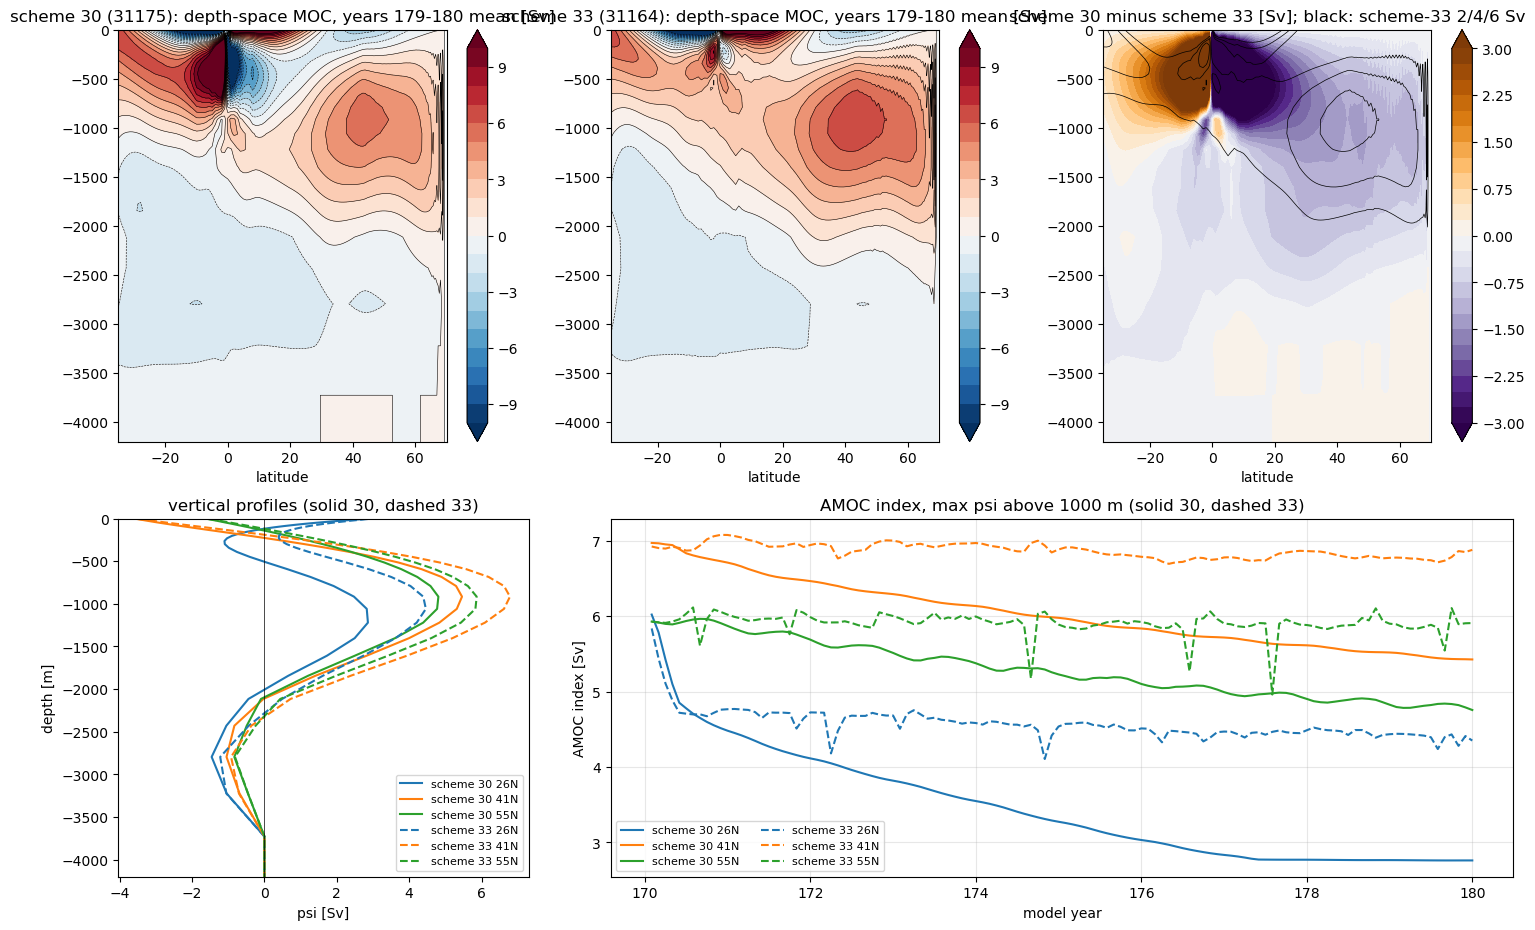

In [6]:
D = {'scheme 30 (31175)': DINOLoader(PAIRS['10yr']['adv30'], prefix=['dynDiag'], geometry='curvilinear', delta_t=1800.),
     'scheme 33 (31164)': DINOLoader(PAIRS['10yr']['adv33'], prefix=['dynDiag'], geometry='curvilinear', delta_t=1800.)}
for d in D.values(): d.compute_moc_diagnostics(target_lat=26., depth_limit=-1000)
k30, k33 = list(D)
z = D[k30].ds.Z.values; lat = D[k30].psi_moc.YC.values
psi = {k: D[k].psi_moc.isel(time=slice(-12, None)).mean('time').transpose('k', 'j_g').values for k in D}
yrs = {k: (np.array(D[k].ds.iter.values) - 2986560) / 48. / 366. + 170 for k in D}
fig = plt.figure(figsize=(18, 11)); gs = fig.add_gridspec(2, 3, height_ratios=[1.15, 1]); lev = np.linspace(-10, 10, 21)
for i, k in enumerate(D):
    ax = fig.add_subplot(gs[0, i]); cf = ax.contourf(lat, z, psi[k], levels=lev, cmap='RdBu_r', extend='both')
    ax.contour(lat, z, psi[k], levels=lev, colors='k', linewidths=0.4); ax.set_xlim(-35, 70); ax.set_ylim(-4200, 0)
    ax.set_title(f'{k}: depth-space MOC, years 179-180 mean [Sv]'); ax.set_xlabel('latitude'); fig.colorbar(cf, ax=ax)
ax = fig.add_subplot(gs[0, 2]); cf = ax.contourf(lat, z, psi[k30] - psi[k33], levels=np.linspace(-3, 3, 25), cmap='PuOr_r', extend='both')
ax.contour(lat, z, psi[k33], levels=[2, 4, 6], colors='k', linewidths=0.5); ax.set_xlim(-35, 70); ax.set_ylim(-4200, 0)
ax.set_title('scheme 30 minus scheme 33 [Sv]; black: scheme-33 2/4/6 Sv'); ax.set_xlabel('latitude'); fig.colorbar(cf, ax=ax)
ax = fig.add_subplot(gs[1, 0])
for k, ls in ((k30, '-'), (k33, '--')):
    for latp, c in ((26, 'C0'), (41, 'C1'), (55, 'C2')):
        j = int(np.abs(lat - latp).argmin()); ax.plot(psi[k][:, j], z, ls, color=c, label=f'{k[:9]} {latp}N')
ax.axvline(0, color='k', lw=0.5); ax.set_xlabel('psi [Sv]'); ax.set_ylabel('depth [m]'); ax.set_title('vertical profiles (solid 30, dashed 33)'); ax.legend(fontsize=8); ax.set_ylim(-4200, 0)
ax = fig.add_subplot(gs[1, 1:])
for k, ls in ((k30, '-'), (k33, '--')):
    P = D[k].psi_moc.transpose('time', 'k', 'j_g').values; up = z >= -1000
    for latp, c in ((26, 'C0'), (41, 'C1'), (55, 'C2')):
        j = int(np.abs(lat - latp).argmin()); s = np.nanmax(P[:, up, j], axis=1); ax.plot(yrs[k], s, ls, color=c, label=f'{k[:9]} {latp}N')
        print(f'{k} {latp}N: AMOC index yr1 {s[:12].mean():.2f}, yr5 {s[48:60].mean():.2f}, yr10 {s[-12:].mean():.2f} Sv')
ax.set_xlabel('model year'); ax.set_ylabel('AMOC index [Sv]'); ax.set_title('AMOC index, max psi above 1000 m (solid 30, dashed 33)'); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
fig.savefig(f'{FIG_DIR}/amoc_structure_from170yrPk_10yr_adv30_vs_adv33.png', dpi=110, bbox_inches='tight')

## Reading

- Poleward of 15° the two schemes give overturning cells of the **same vertical extent** (bottom of the upper cell at 2100–2400 m in both, the scheme-30 zero crossing at 26° N slightly shallower, 2115 vs 2429 m); under scheme 30 the cell is weaker, by 0.3–0.6 Sv at 2 yr and 1.1–1.6 Sv at 10 yr (2.8 vs 4.4 Sv at 26° N, 5.5 vs 6.8 at 41° N, 4.8 vs 5.9 at 55° N), a steady decline over the decade that has only begun to flatten.
- Within ±10° of the equator the tropical cells are stronger (22 vs 8.5 Sv) **and deeper** under scheme 30 (the counter-clockwise cell north of the equator reaches ~900 m instead of ~300 m). If scheme-30 cells were seen to "extend too deep", this equatorial pair is what it was.
- Over/undershoots are negligible in this mature state (no salinity cell outside the limited run's range; one surface cell per month above its temperature maximum); mixed-layer statistics are identical.
- The mechanism is the limiter's implicit vertical mixing at the sharp equatorial thermocline under strong upwelling; removing it leaves a thermocline 0.5–1.1 °C colder through 400 m, upwelling confined to the top 150 m, a mean ocean 0.02 °C cooler and 15 % more kinetic energy after a decade. Which equatorial structure is closer to DINO's own (NEMO, FCT — a limited scheme) is not decidable from these runs.